# **Identificação**:

- `Número de aluno`:
- `Nome`:
- `Data`: / /

# **Instruções:**
- Justifique suas respostas quando solicitado.
- Não é permitido a consulta a outros alunos ou a qualquer material externo.
- Eletronic devices estão proibidos durante o teste.
- Teste seus códigos com diferentes entradas para garantir seu funcionamento.
- Salve o notebook com seu `número de aluno` antes de entregar. Exemplo: `2022000000.ipynb`.
- Faça silêncio em respeito aos alunos que ainda estão realizando o teste.

## Importando bibliotecas

Espere cada uma das instalações terminar antes de rodar a célula seguinte

In [ ]:
!pip install numpy==1.24.4 scipy==1.10.1 gensim==4.3.3 umap umap-learn

Confirme que deseja REINICIAR a SESSÃO

In [ ]:
!pip install spacy nltk
!python -m spacy download pt_core_news_sm
!pip install scikit-learn

In [ ]:
!pip install pandas networkx matplotlib

In [ ]:
!pip install pyLDAvis

In [ ]:
# Instalar o Graphviz e PyGraphviz
!apt-get install -y graphviz libgraphviz-dev
!pip install pygraphviz

In [5]:
import numpy as np
import networkx as nx

# **Questões:**

## 1. Considerando o grafo abaixo:

In [7]:
# graph
g = {'S': {('A',7),('B',2),('C',3)},
    'A': {('B',3),('D',2),('S',7)},
    'B': {('A',3),('D',4),('H',1),('S',2)},
    'C': {('L',2),('S',3)},
    'D': {('A',4),('B',4),('F',5)},
    'E': {('K',5),('G',2)},
    'F': {('D',5),('H',2)},
    'G': {('H',2),('E',2)},
    'H': {('B',1),('F',4),('G',2)},
    'I':{('L',4),('J',5),('K',4)},
    'J':{('L',4),('I',3),('K',4)},
    'K':{('I',4),('J',1),('E',5)},
    'L':{('C',2),('J',2),('I',4)}
}

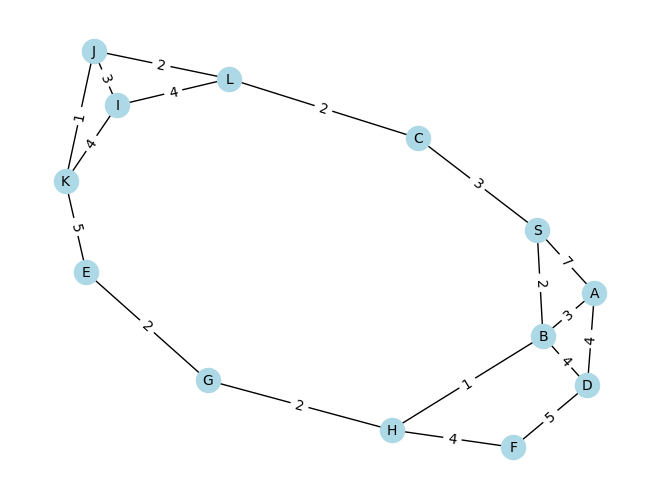

In [ ]:
import matplotlib.pyplot as plt

def show_weighted_graph(graph):
    

    G = nx.Graph()
    for node, edges in graph.items():
        for edge in edges:
            G.add_edge(node, edge[0], weight=edge[1])
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=300, font_size=10)
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    plt.show()

show_weighted_graph(g)

## 1.2. Qual ou quais dos algoritmos abaixo eu poderia utilizar para encontrar o caminho com menor custo no grafo acima?

- a) [ ] Breadth-First Search (BFS)
- b) [ ] Depth-First Search (DFS)
- c) [ ] Dijkstra
- d) [ ] Minimax

In [ ]:
# c) Dijkstra

## 1.3. Explique sua escolha(s) na questão anterior:

In [ ]:
# Dijkstra é o único algoritmo da lista que garante encontrar o caminho de menor custo em grafos com pesos positivos. BFS e DFS não consideram pesos das arestas, apenas o número de arestas. Minimax é usado para jogos adversariais, não para busca de menor caminho.

## 1.4. Partindo do nó inicial "J" (`start_node = 'J'`) e tendo como objetivo chegar ao nó "D" (`goal_node = 'E'`), qual o caminho e menor custo possível?

In [ ]:
# start node
start_node = 'J'

# goal node
goal_node = 'D'

In [ ]:
import heapq

def dijkstra(graph, start, goal):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {}
    pq = [(0, start)]
    
    while pq:
        current_distance, current = heapq.heappop(pq)
        
        if current == goal:
            path = []
            while current in previous:
                path.append(current)
                current = previous[current]
            path.append(start)
            return path[::-1], distances[goal]
        
        if current_distance > distances[current]:
            continue
            
        for neighbor, weight in graph[current]:
            distance = current_distance + weight
            
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current
                heapq.heappush(pq, (distance, neighbor))
    
    return None, float('inf')

path, cost = dijkstra(g, start_node, goal_node)
print(f"Caminho: {' -> '.join(path)}")
print(f"Custo: {cost}")

## 2. Considerando o grafo abaixo, escolha um dos algoritmos da lista abaixo e encontre o nó desejado:

- Breadth-First Search (BFS)
- Depth-First Search (DFS)
- Dijkstra
- Minimax

**A solução deve conter o caminho utilizado**
- Exemplo:
    - para `nó inicial A` e `nó objetivo H`:
    - Caminho: ACDBFGDGH



In [ ]:
grafo = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F', 'G'],
    'D': ['B'],
    'E': ['B', 'H'],
    'F': ['C'],
    'G': ['C'],
    'H': ['E']
}

def bfs(graph, start, goal):
    from collections import deque
    queue = deque([(start, [start])])
    visited = set()
    
    while queue:
        node, path = queue.popleft()
        
        if node == goal:
            return path
            
        if node not in visited:
            visited.add(node)
            
            for neighbor in graph[node]:
                if neighbor not in visited:
                    queue.append((neighbor, path + [neighbor]))
    
    return None

**A funçao abaixo pode auxiliar na visualização de seu grafo...**

In [ ]:
def show_graph(graph):
    
    G = nx.Graph(graph)
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=300, font_size=10)

    plt.show()

## 2.1. `Nó inicial A` e `nó objetivo H`

In [ ]:
path_ah = bfs(grafo, 'A', 'H')
print(f"Caminho A->H: {''.join(path_ah)}")

## 2.2. `Nó inicial A` e `nó objetivo F`

In [ ]:
path_af = bfs(grafo, 'A', 'F')
print(f"Caminho A->F: {''.join(path_af)}")

a) Queue

## 2.4. Quando usamos o algoritmo de busca em profundidade (DFS), uma vez que tenhamos percorrido todo um caminho na árvore (galho) e não encontramos o nó desejado, o que acontece?

In [ ]:
# No DFS, quando chegamos ao final de um galho (caminho) sem encontrar o nó objetivo, fazemos backtracking - retornamos ao nó anterior e exploramos outros caminhos ainda não visitados. O algoritmo continua até encontrar o objetivo ou esgotar todas as possibilidades.

## 2.5. Qual algoritmo de busca da lista abaixo garante que se encontra o menor caminho?

- a) [ ] Breadth-First Search (BFS)
- b) [ ] Depth-First Search (DFS)

In [ ]:
# a) Breadth-First Search (BFS)

# 3. Considerando que o grafo abaixo representa os estados possíveis após turnos alternados entre o Jogador 1 (Player 1 - P1) e o Jogador 2 (Player 2 - P2):

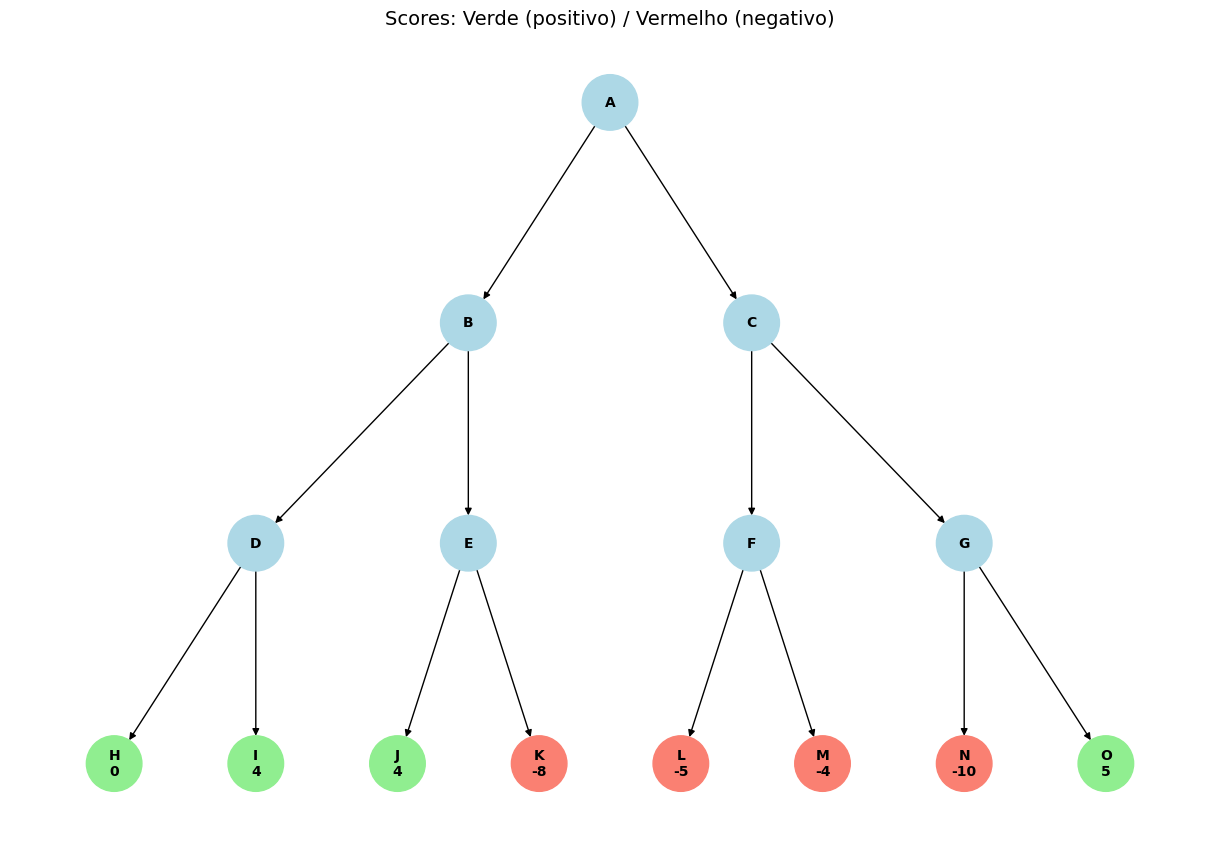

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_agraph import graphviz_layout

edges = [
    (0, 1), (0, 2),
    (1, 3), (1, 4),
    (2, 5), (2, 6),
    (3, 7), (3, 8),
    (4, 9), (4, 10),
    (5, 11), (5, 12),
    (6, 13), (6, 14),
]


values = {
    7: 0, 8: 4, 9: 4, 10: -8, 11: -5, 12: -4, 13: -10, 14: 5
}


labels = {i: chr(65 + i) for i in range(15)}


G = nx.DiGraph()
G.add_edges_from(edges)


for node in G.nodes:
    G.nodes[node]["value"] = values.get(node, None)

leaf_nodes = [n for n in G.nodes if G.out_degree(n) == 0]


colors = []
for n in G.nodes:
    if n in leaf_nodes:
        val = G.nodes[n]["value"]
        if val is not None and val >= 0:
            colors.append('lightgreen')
        elif val is not None and val < 0:
            colors.append('salmon')
        else:
            colors.append('lightgray')
    else:
        colors.append('lightblue')


display_labels = {}
for n in G.nodes:
    if n in leaf_nodes and G.nodes[n]["value"] is not None:
        display_labels[n] = f"{labels[n]}\n{G.nodes[n]['value']}"
    else:
        display_labels[n] = labels[n]


pos = graphviz_layout(G, prog="dot")


plt.figure(figsize=(12, 8))
nx.draw(G, pos,
        with_labels=True,
        labels=display_labels,
        node_color=colors,
        node_size=1600,
        font_weight="bold",
        font_size=10,
        arrows=True)

plt.title("Scores: Verde (positivo) / Vermelho (negativo)", fontsize=14)
plt.axis("off")
plt.show()


## 3.1. Implemente o Minimax (Busca Adversarial) e responda qual o melhor score possível para o Jogador 1 considerando que este é o primeiro a jogar.

In [ ]:
def minimax(node, depth, is_maximizing, values):
    if depth == 0 or node in values:
        return values.get(node, 0)
    
    if is_maximizing:
        max_eval = float('-inf')
        for child in get_children(node):
            eval_score = minimax(child, depth - 1, False, values)
            max_eval = max(max_eval, eval_score)
        return max_eval
    else:
        min_eval = float('inf')
        for child in get_children(node):
            eval_score = minimax(child, depth - 1, True, values)
            min_eval = min(min_eval, eval_score)
        return min_eval

def get_children(node):
    children_map = {
        0: [1, 2],
        1: [3, 4],
        2: [5, 6],
        3: [7, 8],
        4: [9, 10],
        5: [11, 12],
        6: [13, 14]
    }
    return children_map.get(node, [])

leaf_values = {7: 0, 8: 4, 9: 4, 10: -8, 11: -5, 12: -4, 13: -10, 14: 5}

best_score = minimax(0, 3, True, leaf_values)
print(f"Melhor score para o Jogador 1: {best_score}")

# 4. Considerando o dataset fornecido:

In [ ]:
!pip install numpy==1.24.4 scipy==1.10.1 nltk

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop = list(set(stopwords.words('portuguese')))
import gensim
import gensim.corpora as corpora
from gensim.models.ldamodel import LdaModel

In [ ]:
import pandas as pd

df_train = pd.read_csv("sinopsys_train.csv")
df_test = pd.read_csv("sinopsys_test.csv")

df_train.head()

,titulo,sinopse,generos,is_valid
0,We Were Soldiers,A história da primeira grande batalha da fase ...,"['Ação', 'História', 'Guerra']",False
1,4Got10,"Um negócio de drogas dá errado, deixando corpo...","['Ação', 'Crime', 'Thriller']",False
2,Pontypool,Quando o disc jockey Grant Mazzy se reporta à ...,"['Horror', 'Mistério', 'Ficção Científica']",False
3,Ticker,Depois que o parceiro de um detetive de São Fr...,"['Ação', 'Crime', 'Thriller']",False
4,Real Genius,Um adolescente prodígio tenso entra em uma fac...,"['Comédia', 'Romance', 'Ficção Científica']",True


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


corpus = df_train["sinopse"].dropna().astype(str).tolist()
corpus[:10]

['A história da primeira grande batalha da fase americana da Guerra do Vietnã e os soldados de ambos os lados que a travaram.',
 'Um negócio de drogas dá errado, deixando corpos. Um xerife atira em seu vice pelo dinheiro e um amnésico ferido atira no xerife e foge com $ 3.000.000. A DEA investiga, assim como o traficante pai do deputado morto.',
 'Quando o disc jockey Grant Mazzy se reporta à estação de rádio de seu porão na cidade canadense de Pontypool, ele pensa que é apenas mais um dia de trabalho. Mas quando ouve relatos de um vírus que transforma as pessoas em zumbis, Mazzy se barrica na cabine de rádio e tenta descobrir uma maneira de alertar seus ouvintes sobre o vírus e seu improvável modo de transmissão.',
 'Depois que o parceiro de um detetive de São Francisco é assassinado por terroristas da Irlanda do Norte, o policial se junta ao esquadrão antibomba para levá-los à justiça.',
 'Um adolescente prodígio tenso entra em uma faculdade de engenharia de ponta, mas se sente estra

## 4.1. Crie uma função que implemente um pipeline de préprocessamento apropriado

In [ ]:
import re
import string

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    words = text.split()
    words = [word for word in words if word not in stop and len(word) > 2]
    return ' '.join(words)

processed_corpus = [preprocess_text(text) for text in corpus]
processed_corpus[:3]

## 4.2. Represente através de uma matriz TF-IDF.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf.fit_transform(processed_corpus)

print(f"Forma da matriz TF-IDF: {tfidf_matrix.shape}")
print(f"Primeiros 5 features: {tfidf.get_feature_names_out()[:5]}")

## 4.3. Quais os top-10 palavras com TF-IDF mais alto corpus que não sejam stopwords?

In [ ]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
mean_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()

word_scores = list(zip(feature_names, mean_scores))
word_scores.sort(key=lambda x: x[1], reverse=True)

print("Top-10 palavras com maior TF-IDF (excluindo stopwords):")
for i, (word, score) in enumerate(word_scores[:10]):
    print(f"{i+1}. {word}: {score:.4f}")

## 4.4. Calcule a similaridade cosseno entre dois documentos à sua escolha e comente o resultado.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

doc1_idx = 0
doc2_idx = 1

doc1_vector = tfidf_matrix[doc1_idx]
doc2_vector = tfidf_matrix[doc2_idx]

similarity = cosine_similarity(doc1_vector, doc2_vector)[0][0]

print(f"Similaridade cosseno entre documento {doc1_idx} e {doc2_idx}: {similarity:.4f}")
print(f"\nDocumento {doc1_idx}: {corpus[doc1_idx][:100]}...")
print(f"\nDocumento {doc2_idx}: {corpus[doc2_idx][:100]}...")
print(f"\nComentário: Similaridade de {similarity:.4f} indica {'alta' if similarity > 0.3 else 'baixa'} similaridade semântica entre os documentos.")

## 4.5.Implemente o Word2Vec e selecione umá palavra presente no corpus (**a seu critério**) e preveja um contexto. Qual contexto o modelo preveu?

In [ ]:
from gensim.models import Word2Vec

tokenized_corpus = [text.split() for text in processed_corpus]

w2v_model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5, min_count=2, workers=4, sg=1)

target_word = "filme"
context_words = w2v_model.wv.most_similar(target_word, topn=5)

print(f"Palavra escolhida: '{target_word}'")
print(f"Contexto previsto pelo modelo (palavras mais similares):")
for word, similarity in context_words:
    print(f"  {word}: {similarity:.4f}")

## 4.6. A abordagem acima foi:

- a) [ ] Skip-gram
- b) [ ] CBOW

In [ ]:
# a) Skip-gram

## 4.7. Explique a diferença entre usar o CBOW e o SKip-Gram.

In [ ]:
# CBOW (Continuous Bag of Words) prediz uma palavra central a partir das palavras do contexto ao redor. Skip-gram faz o oposto: prediz as palavras do contexto a partir de uma palavra central. Skip-gram funciona melhor com corpus pequenos e palavras raras, enquanto CBOW é mais eficiente computacionalmente e funciona bem com palavras frequentes.

## 4.8. Implemente o LDA

In [ ]:
texts = [text.split() for text in processed_corpus]
id2word = corpora.Dictionary(texts)
corpus = [id2word.doc2bow(text) for text in texts]

lda_model = LdaModel(corpus=corpus, id2word=id2word, num_topics=15, random_state=42, passes=10, alpha='auto', per_word_topics=True)

for idx, topic in lda_model.print_topics(-1):
    print(f'Tópico {idx}: {topic}')
    print()

## 4.9. Selecione um dos Tópicos (**exceto o do exemplo**) e, baseado nos termos, faça uma sugestâo de label que represente bem aquele Tópico.

- **Exemplo**: O Tópico 5 possui predominante termos relacionados a espionagem e guerra. Portanto, um bom label seria Ação e Espionagem Militar.

- Palavras principais deste tópico:
"agente", "guerra", "policial", "mundial", "secreto", "missão", "governo", "investigar", "americano", "eua"

In [ ]:
# Analisando o Tópico 3, que possui termos como "homem", "vida", "mulher", "jovem", "família", "casa", "encontra", "amor", "tenta", "volta", sugiro o label "Drama Familiar e Relacionamentos". Este tópico claramente representa filmes focados em relacionamentos humanos, dramas familiares e histórias pessoais de personagens em suas vidas cotidianas.

A visualização abaixo pode auxiliar na identificação dos tópicos para responder a questão 4.9 - ajuste conforme sua necessidade

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models

pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
9      0.097808 -0.038625       1        1  8.249000
7      0.062973  0.079715       2        1  7.728409
13    -0.134500 -0.068400       3        1  7.477168
12    -0.059845 -0.009418       4        1  7.265982
0      0.008842 -0.102658       5        1  7.119880
6     -0.056911  0.104923       6        1  6.876232
5     -0.019704  0.062981       7        1  6.812886
14    -0.055219  0.012074       8        1  6.734138
8     -0.018803 -0.004649       9        1  6.614288
11     0.016423  0.051629      10        1  6.372559
2      0.032145 -0.056504      11        1  6.267823
4      0.061620 -0.021034      12        1  6.255464
1      0.020639  0.027487      13        1  5.856819
3      0.019045 -0.053909      14        1  5.580602
10     0.025488  0.016389      15        1  4.788752, topic_info=         Term       Freq      Total Category  logprob  loglift
173     jovem  67.000000  67.000000  Default  30.0000  30.0000
356   família  63.000000  63.000000  Default  29.0000  29.0000
124      casa  57.000000  57.000000  Default  28.0000  28.0000
787     filme  38.000000  38.000000  Default  27.0000  27.0000
40        dia  19.000000  19.000000  Default  26.0000  26.0000
..        ...        ...        ...      ...      ...      ...
529  enquanto   2.534216  80.690736  Topic15  -6.1115  -0.4218
597      novo   2.084788  30.013067  Topic15  -6.3067   0.3719
409       the   2.055522  25.756388  Topic15  -6.3209   0.5107
352    contra   2.055502  42.307054  Topic15  -6.3209   0.0145
558    equipe   2.055307  21.228051  Topic15  -6.3210   0.7040

[1077 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
8029      5  0.673681       1
801       3  0.224400      12
801       5  0.448799      12
801       8  0.224400      12
603      12  0.560005      16
...     ...       ...     ...
2169      4  0.103001  último
2169      5  0.103001  último
2169      6  0.103001  último
2169      7  0.103001  último
2169      8  0.206001  último

[2752 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[10, 8, 14, 13, 1, 7, 6, 15, 9, 12, 3, 5, 2, 4, 11])